# **Fraud Detection :>**
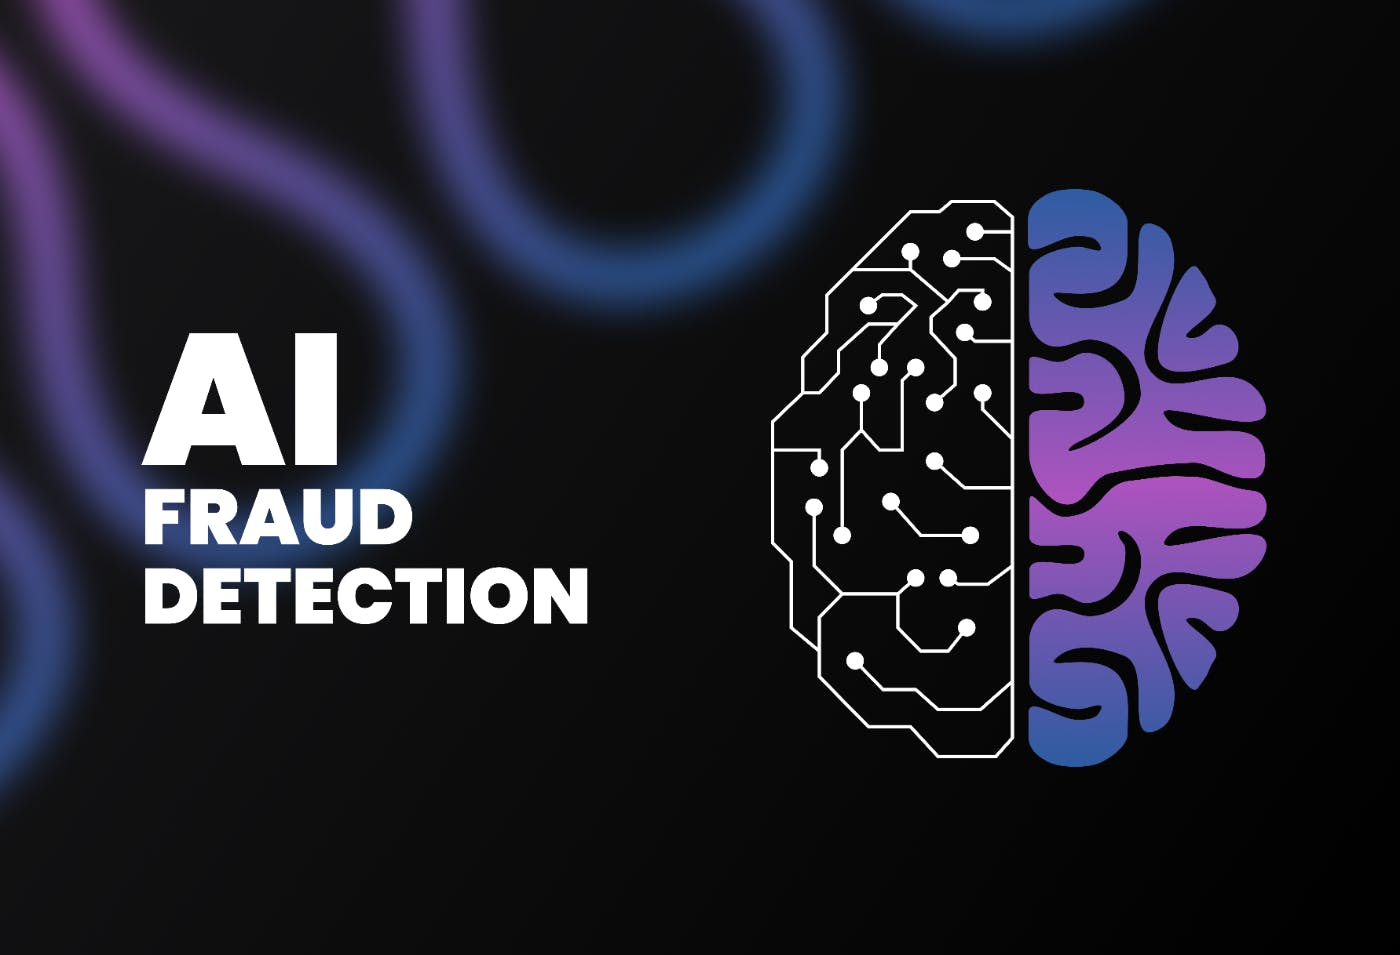


**What is fraud detection ?**

Fraud detection is the process of identifying and mitigating fraudulent activities or attempts within a system or organization. It involves monitoring transactions, behaviors, and patterns to detect anomalies or suspicious activities indicative of fraud.

***
**Applications of Fraud Detection :**

1-Banking & financial services

2-Ecommerce & retail

3-Marketplaces & online ads

***

**What is the most imporatant features to detect fraud ?**

1-Transaction recency (time passed since last purchase)

2-Frequency (number of transactions)

3-Monetary values (dollar amount of transactions)


***

# **Project Objective :**

This project aims to develop a machine learning system that identifies fraudulent transactions in real
time using a historical dataset of financial transactions for many reasons such as :
Identifying fraudulent transactions early, financial institutions can prevent financial losses associated
with fraudulent activities.
Minimizing false positives, legitimate transactions won't be declined, leading to a smoother customer
experience.
A robust fraud detection system can deter fraudulent activities and improve overall financial security.
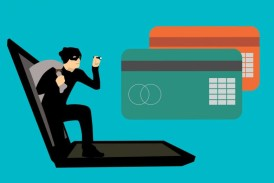
***

# **Importing libraries :-->**

In [1]:
# For Numirecal Functions
import numpy as np
# For dataFrame Functions
import pandas as pd
# For Analysis & Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# For Balancing data
from imblearn.over_sampling import SMOTE
# For Spilit data
from sklearn.model_selection import train_test_split

# **Importing Data :-->**

In [2]:
data=pd.read_csv('fraudTrain.csv')

# **Exploring Data :-->**

In [3]:
# To know the number of rows & columns
data.shape

(1002104, 10)

In [4]:
# To know the size of data
data.size

10021040

In [5]:
# To See the first five rows from data
data.head()

,ID,Time,Card Number,merchant,category,Amount,firstName,lastName,trans_num,is_fraud
0,0,1/1/2019 0:00,2.700000e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,0b242abb623afc578575680df30655b9,0.0
1,1,1/1/2019 0:00,6.300000e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,1f76529f8574734946361c461b024d99,0.0
2,2,1/1/2019 0:00,3.890000e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,a1a22d70485983eac12b5b88dad1cf95,0.0
3,3,1/1/2019 0:01,3.530000e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,6b849c168bdad6f867558c3793159a81,0.0
4,4,1/1/2019 0:03,3.760000e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,a41d7549acf90789359a9aa5346dcb46,0.0


In [7]:
data['category'].value_counts()

gas_transport     101728
grocery_pos        95341
home               95175
shopping_pos       90140
kids_pets          87321
shopping_net       75411
entertainment      72707
food_dining        70862
personal_care      70309
health_fitness     66267
misc_pos           61658
misc_net           48756
grocery_net        35061
travel             31367
kids_                  1
Name: category, dtype: int64

In [8]:
# To see columns names
data.columns

Index(['ID', 'Time', 'Card Number', 'merchant', 'category', 'Amount',
       'firstName', 'lastName', 'trans_num', 'is_fraud'],
      dtype='object')

In [9]:
# To see some information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002104 entries, 0 to 1002103
Data columns (total 10 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   ID           1002104 non-null  int64  
 1   Time         1002104 non-null  object 
 2   Card Number  1002104 non-null  float64
 3   merchant     1002104 non-null  object 
 4   category     1002104 non-null  object 
 5   Amount       1002103 non-null  float64
 6   firstName    1002103 non-null  object 
 7   lastName     1002103 non-null  object 
 8   trans_num    1002103 non-null  object 
 9   is_fraud     1002103 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 76.5+ MB


In [10]:
#Some information about transaction amount
data['Amount'].describe()

count    1.002103e+06
mean     7.025616e+01
std      1.602039e+02
min      1.000000e+00
25%      9.640000e+00
50%      4.742000e+01
75%      8.304000e+01
max      2.894890e+04
Name: Amount, dtype: float64

In [11]:
# check if there are invaild values in the output
bools = ((data['is_fraud'] != 0.0) & (data['is_fraud'] != 1.0))
bools.sum()

1

In [12]:
# To check if there is duplication in data or not
data.duplicated().sum()

0

In [13]:
# To know the total nulls in each column
data.isnull().sum()

ID             0
Time           0
Card Number    0
merchant       0
category       0
Amount         1
firstName      1
lastName       1
trans_num      1
is_fraud       1
dtype: int64

In [14]:
# To check nulls is label column
data['is_fraud'].isnull().sum()

1

In [15]:
data[data['ID']==1002103]

,ID,Time,Card Number,merchant,category,Amount,firstName,lastName,trans_num,is_fraud
1002103,1002103,2/15/2020 16:43,2.270000e+15,fraud_Brown Inc,kids_,NaN,NaN,NaN,NaN,NaN


**Exploring Conclusion :-->**

Now , after exploring data we know information about data's features

and also w checked for some properties in data and we found 1 row contain null

# **Feature Engineering :-->**



In [16]:
data.head(2)

,ID,Time,Card Number,merchant,category,Amount,firstName,lastName,trans_num,is_fraud
0,0,1/1/2019 0:00,2.700000e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,0b242abb623afc578575680df30655b9,0.0
1,1,1/1/2019 0:00,6.300000e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,1f76529f8574734946361c461b024d99,0.0


In [17]:
# Sorting
data = data.sort_values(['Card Number', 'Time'])

In [18]:
# Grouping
data['Time'] = pd.to_datetime(data["Time"])
data['Time_Difference'] = data.groupby('Card Number')['Time'].diff()

In [19]:
# Make new featrue from the existing one
data['Hour']=data['Time'].astype(str).apply(lambda x:x.split()[1].split(':')[0])
data['Hour'] = data['Hour'].astype(int)

In [20]:
# Make new featrue from the existing one
data['Minute']=data['Time'].astype(str).apply(lambda x:x.split(':')[1])
data['Minute'] = data['Minute'].astype(int)

In [21]:
## convert Time feature to datetime type
data['Time'] = pd.to_datetime(data["Time"]).dt.date.astype("datetime64[ns]")

In [22]:
# Make new featrue from the existing one
data['month'] = data['Time'].dt.month

In [23]:
# Make new featrue from the existing one
data['weekday'] = data['Time'].dt.dayofweek

In [24]:
# Make new featrue from the existing one
data['day'] = data['Time'].dt.day

In [25]:
# Make new featrue from the existing one
data['year'] = data['Time'].dt.year

In [26]:
# Grouping
average_amounts = data.groupby('category')['Amount'].mean()

In [27]:
# Merge average amounts back into the original DataFrame
data = data.merge(average_amounts, on='category', suffixes=['', '_average'])

In [28]:
# Compute the difference between current and average transaction amount
data['Trasaction_Diff'] = np.abs(data['Amount'] - data['Amount_average'])

In [29]:
# Create new function that calculate the status of time
def map_time_period(hour):
    if 1 <= hour <= 17:
        return 'Day'
    else:
        return 'Night'

In [30]:
data['Time_Period'] = data['Hour'].apply(map_time_period)

In [ ]:
data.tail(2)

**Feature Engineering conculsion :-->**

we create new features from existing ones that might be more informative for fraud detection



# **Statistical Analysis & Visualization :-->**

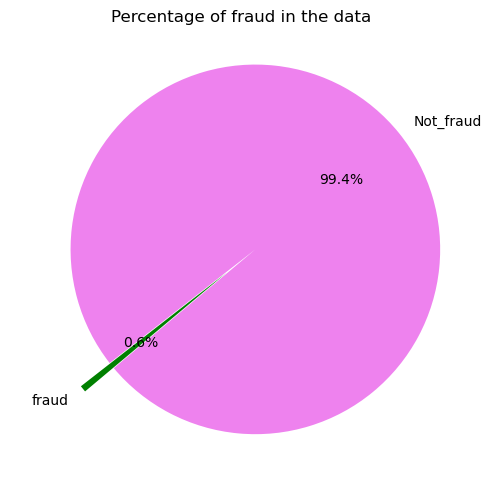

In [31]:
labels ='Not_fraud','fraud'
sizes = data['is_fraud'].value_counts()

colors = ["violet","green"]
explode = (0.1,0.1)

plt.figure(figsize=(6,6))
plt.pie(sizes,labels=labels,explode=explode,  colors=colors, autopct='%1.1f%%', startangle=220)

plt.title('Percentage of fraud in the data')
plt.show()

**Conclusion :**
Most of the transactions are not fraud and the data is not balanced absloutly

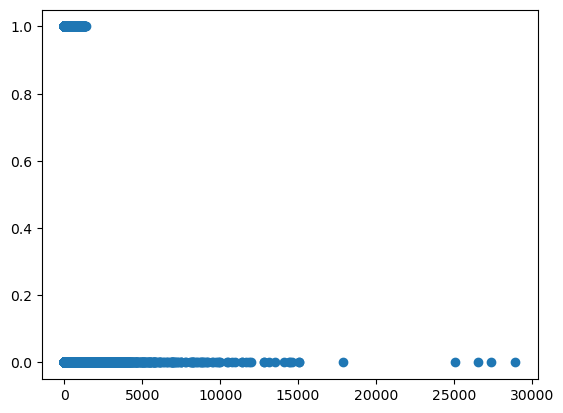

In [32]:
plt.scatter(x='Amount', y='is_fraud', data=data)

**Conclusion :**
This shows that most (all) fraudlent transactions are small transaction (below 5000).

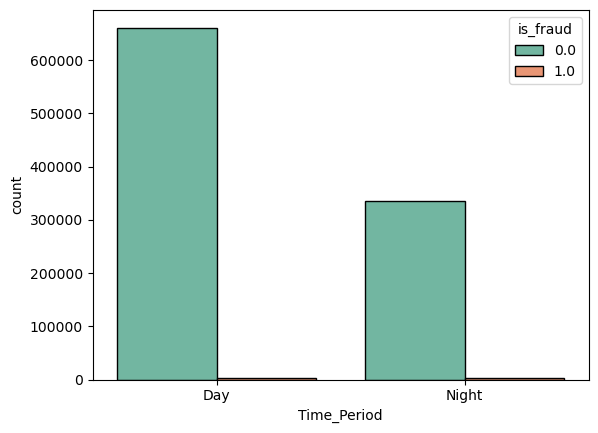

In [33]:
sns.countplot(data, x=data['Time_Period'],palette = 'Set2',hue='is_fraud',edgecolor='black')
plt.show()

**Conclusion :**
Most of the transactions happened during day not Night

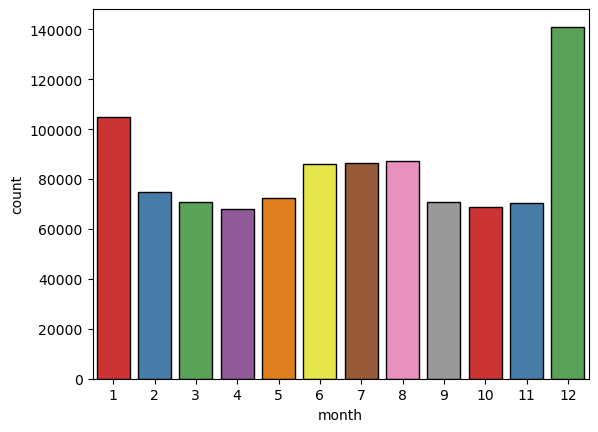

In [34]:
sns.countplot(data, x=data['month'],palette = 'Set1',edgecolor='black')
plt.show()

**Conclusion :**
Most of the transactions happened at December

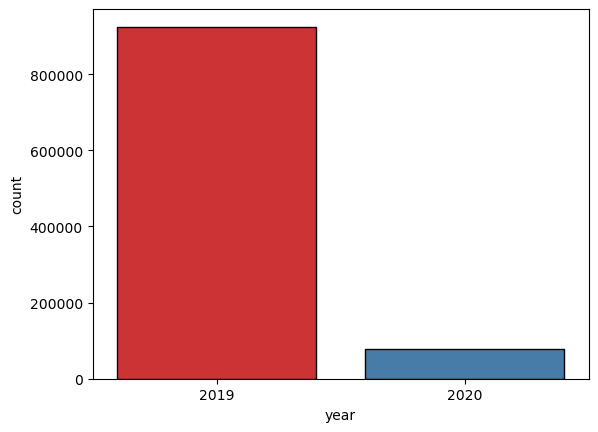

In [35]:
sns.countplot(data, x=data['year'],palette = 'Set1',edgecolor='black')
plt.show()

**Conclusion :**
Most of the transactions happened at 2019

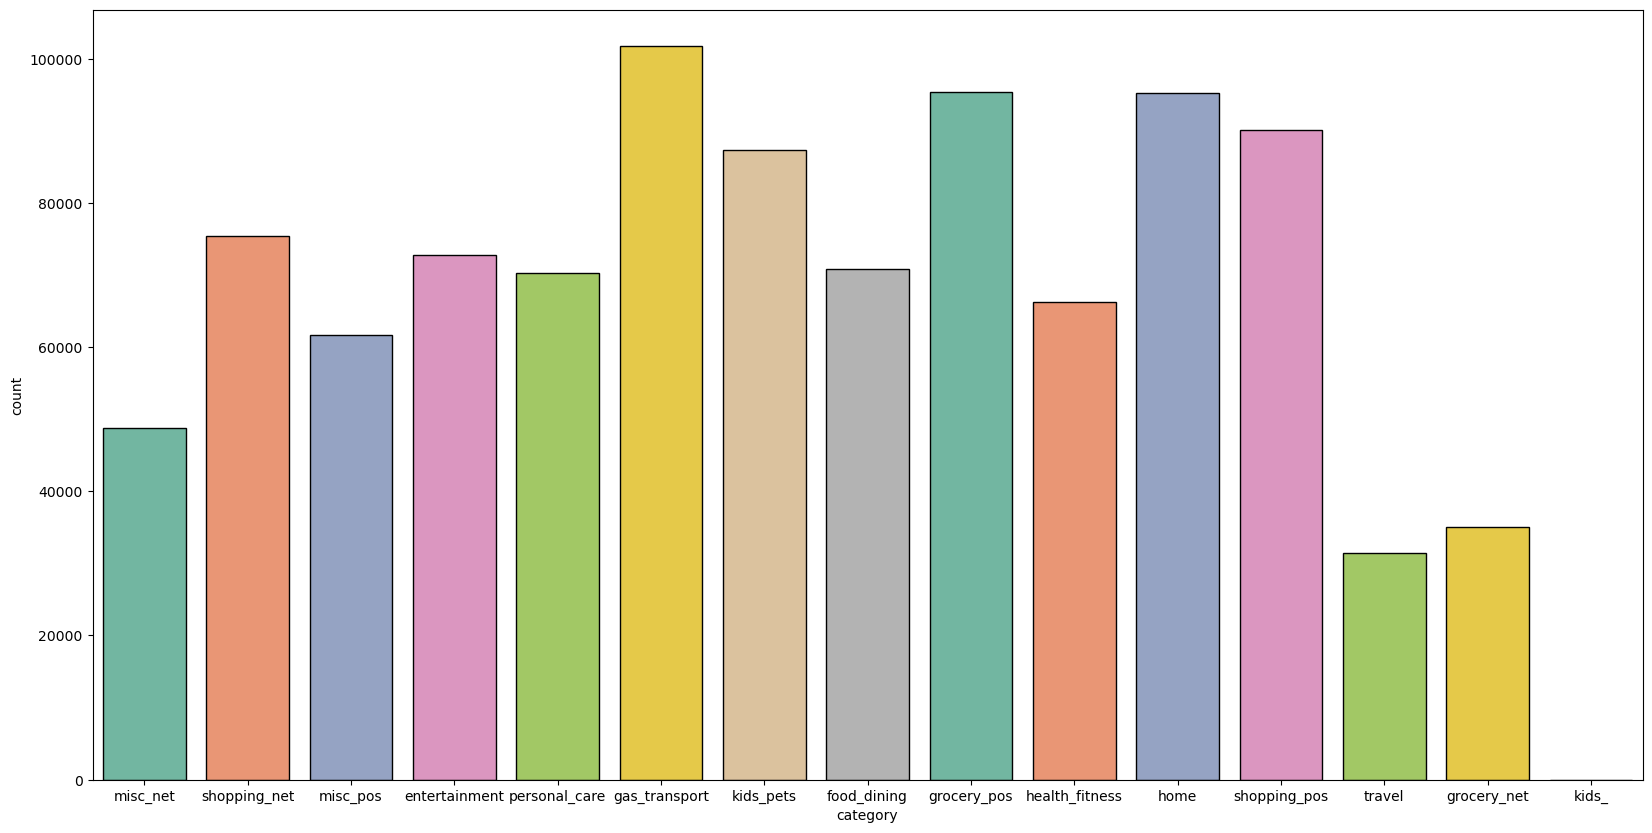

In [36]:
plt.figure(figsize=(20,10))
sns.countplot(data, x=data['category'],palette = 'Set2',edgecolor='black')
plt.show()

**Conclusion :**
Most of the transactions happened at gas_transport ,home and grocery_pos

# **Data Preproccesing :-->**

In [37]:
# First of all we have 1 row conatin nulls in all data so let's drop it :
data.dropna(axis=0,inplace=True)

In [38]:
# in the first transaction in the data for each person
# there is no time difference so we assume it as zero
data['Time_Difference'] = data['Time_Difference'].fillna(pd.Timedelta(0))

In [39]:
# Let's check
data.isnull().sum()

ID                 0
Time               0
Card Number        0
merchant           0
category           0
Amount             0
firstName          0
lastName           0
trans_num          0
is_fraud           0
Time_Difference    0
Hour               0
Minute             0
month              0
weekday            0
day                0
year               0
Amount_average     0
Trasaction_Diff    0
Time_Period        0
dtype: int64

In [40]:
# We have many columns that are not useful in our detection so, let's drop them
data.drop(['ID','merchant','firstName','lastName','trans_num'],axis=1,inplace=True)

In [41]:
data.head(2)

,Time,Card Number,category,Amount,is_fraud,Time_Difference,Hour,Minute,month,weekday,day,year,Amount_average,Trasaction_Diff,Time_Period
1,2019-01-17,6.041621e+10,misc_net,7.16,0.0,0 days 04:10:00,23,34,1,3,17,2019,80.841044,73.681044,Night
2,2019-10-12,6.041621e+10,misc_net,5.27,0.0,0 days 20:36:00,11,32,10,5,12,2019,80.841044,75.571044,Day


In [42]:
data.dtypes

Time                datetime64[ns]
Card Number                float64
category                    object
Amount                     float64
is_fraud                   float64
Time_Difference    timedelta64[ns]
Hour                         int32
Minute                       int32
month                        int64
weekday                      int64
day                          int64
year                         int64
Amount_average             float64
Trasaction_Diff            float64
Time_Period                 object
dtype: object

In [43]:
# Import label encoder
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder

# label_encoder object knows how to understand word labels.
label_encoder = preprocessing.LabelEncoder()
encoder = LabelEncoder()

In [44]:
# Encode labels in column 'category'.
data['category']= label_encoder.fit_transform(data['category'])

In [45]:
data['category'].unique()

array([ 8, 11,  9,  0, 10,  2,  7,  1,  4,  5,  6, 12, 13,  3])

In [46]:
# Encode labels in column 'Time_Period'.
data['Time_Period']= label_encoder.fit_transform(data['Time_Period'])

In [47]:
# Encode labels in column 'Time'.
data['Time'] = encoder.fit_transform(data['Time'])

In [48]:
# Encode labels in column 'Time_Difference'.
data['Time_Difference'] = encoder.fit_transform(data['Time_Difference'].astype(str))

In [49]:
# Check
data.dtypes

Time                 int64
Card Number        float64
category             int32
Amount             float64
is_fraud           float64
Time_Difference      int32
Hour                 int32
Minute               int32
month                int64
weekday              int64
day                  int64
year                 int64
Amount_average     float64
Trasaction_Diff    float64
Time_Period          int32
dtype: object

In [50]:
data.head(2)

,Time,Card Number,category,Amount,is_fraud,Time_Difference,Hour,Minute,month,weekday,day,year,Amount_average,Trasaction_Diff,Time_Period
1,16,6.041621e+10,8,7.16,0.0,10984,23,34,1,3,17,2019,80.841044,73.681044,1
2,284,6.041621e+10,8,5.27,0.0,11970,11,32,10,5,12,2019,80.841044,75.571044,0


# **Feature Selection -->**

In [51]:
from sklearn.feature_selection import SelectKBest, f_classif

X = data.drop(columns='is_fraud')
y = data['is_fraud']
# Perform feature selection
k = 5  # Number of features to select
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)

# Get the selected feature indices
selected_features = selector.get_support(indices=True)

# Create a DataFrame with selected features
df_selected_features = pd.DataFrame(X_new, columns=[f"Feature_{i}" for i in selected_features])

# Print the DataFrame
print(df_selected_features.head())

   Feature_2  Feature_3  Feature_11  Feature_12  Feature_13
0        8.0       7.16   80.841044   73.681044         1.0
1        8.0       5.27   80.841044   75.571044         0.0
2        8.0       4.99   80.841044   75.851044         0.0
3        8.0       8.82   80.841044   72.021044         1.0
4        8.0     133.02   80.841044   52.178956         1.0


In [52]:
# Create a random forest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [53]:
# Fit the model to the training data
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [54]:
# Get feature importances
selecting_features = rf.feature_importances_

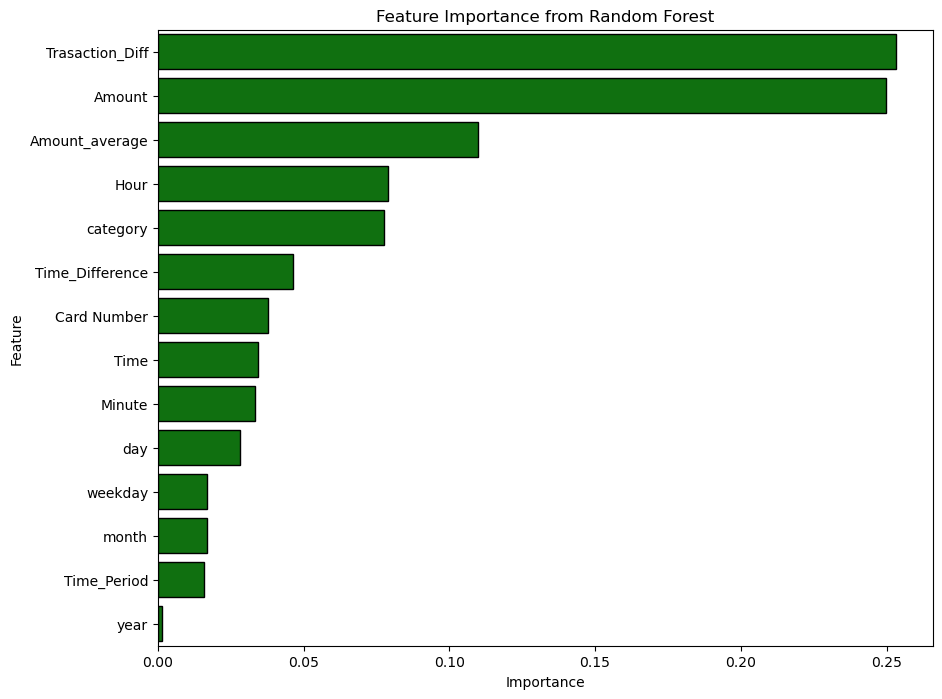

In [55]:
# Create a DataFrame for visualization
importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': selecting_features
})

# Sort the DataFrame by importance in descending order
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(10, 8))
sns.barplot(data=importances_df, x='Importance', y='Feature', color='g',edgecolor='black')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Feature Extraction conclusion-->**

we have {'Amount','transaction difference','Amount AVG','Hour','Category'} are the most 5 feature having strong correlation with the target "is_fraud"..

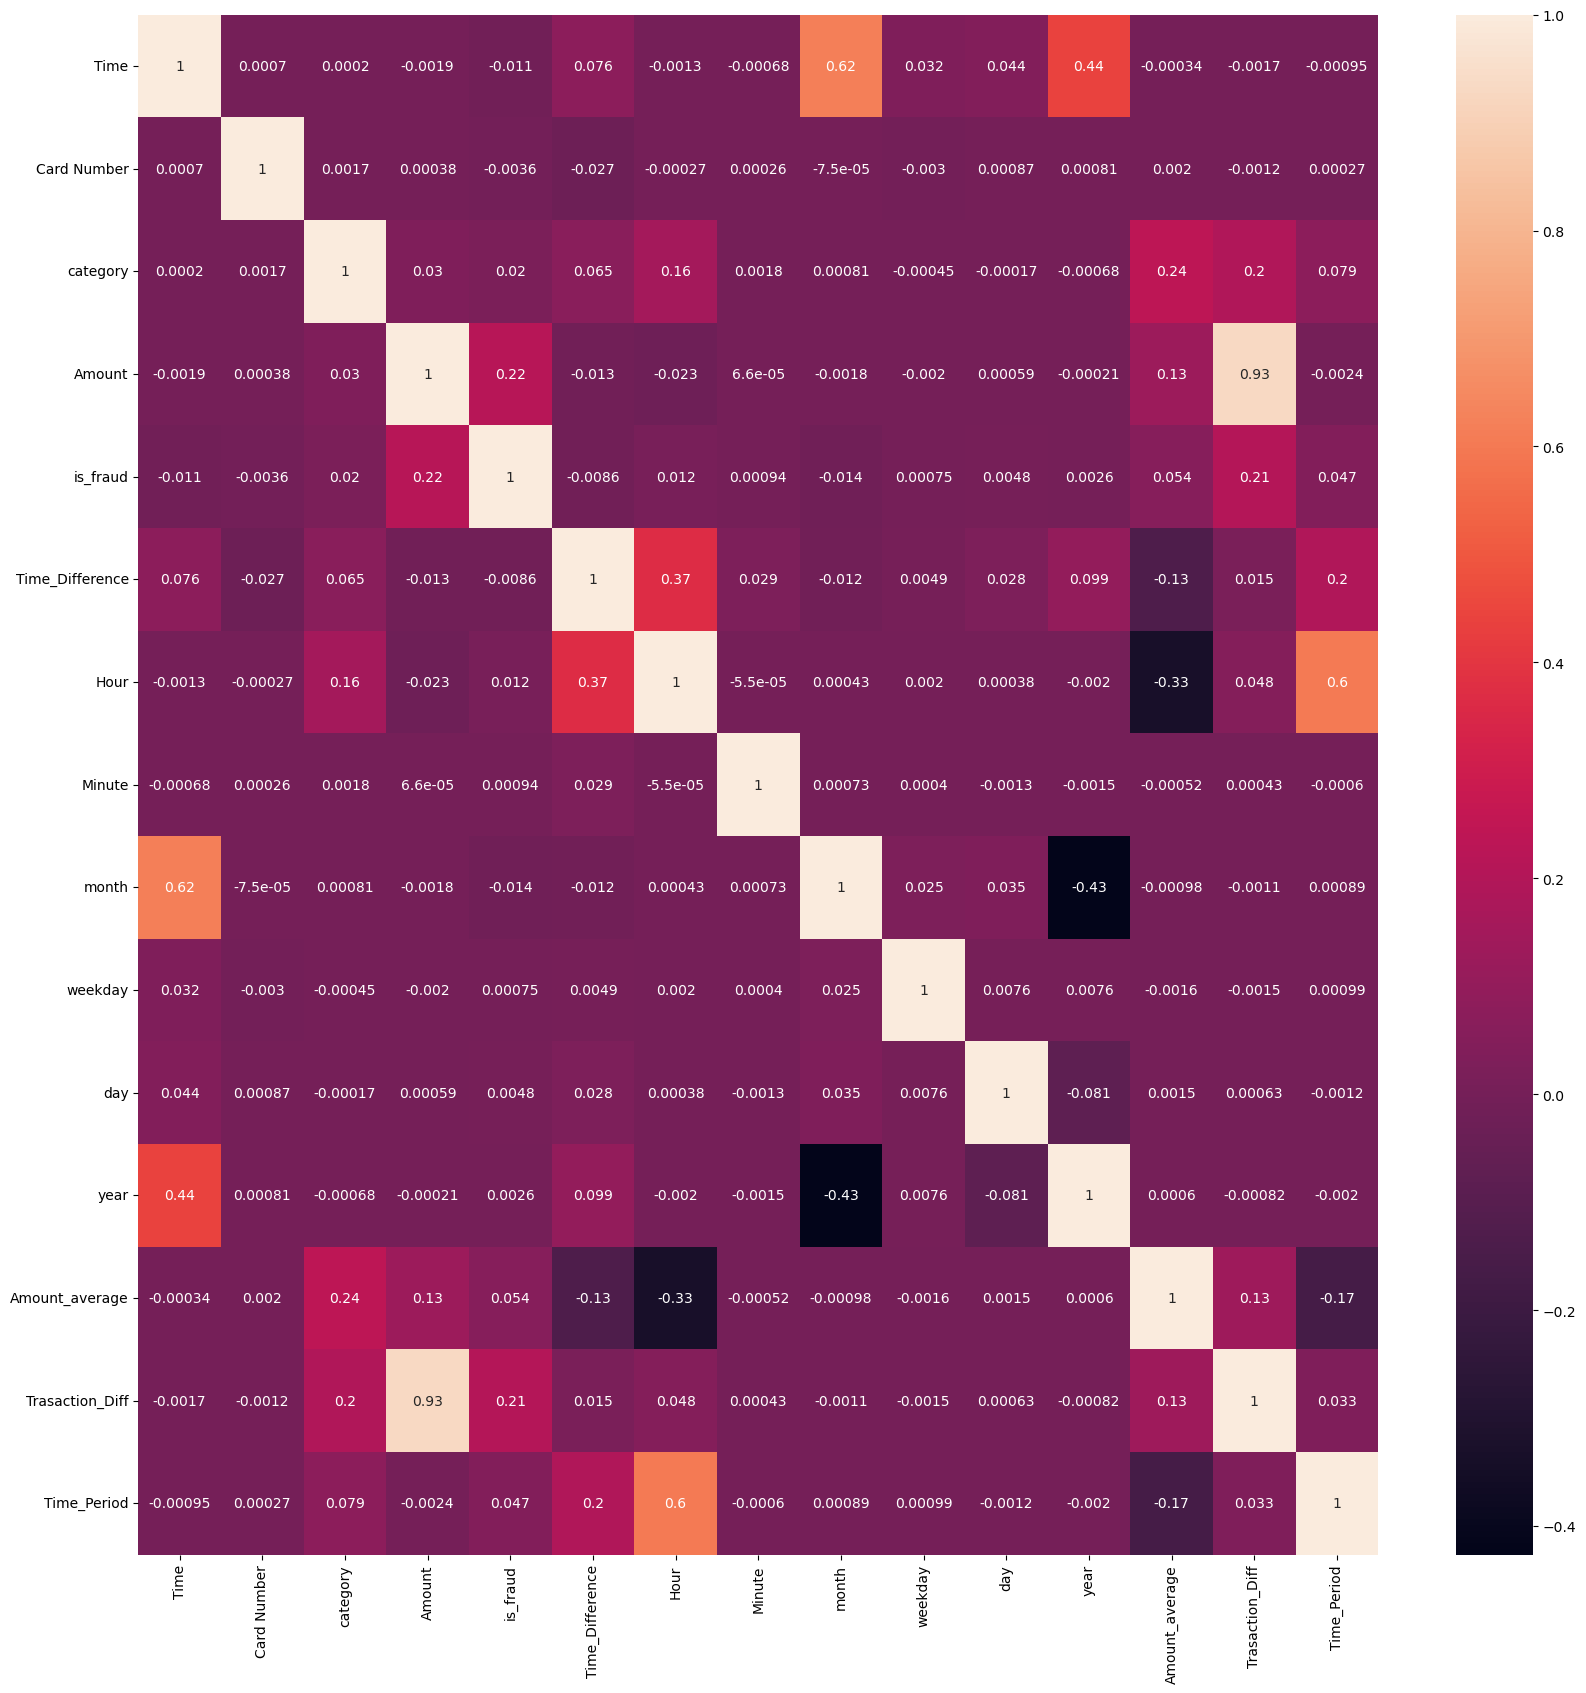

In [79]:
corrmat=data.corr()
top_corr_features=corrmat.index
plt.figure(figsize=(20,20))
g=sns.heatmap(data[top_corr_features].corr(),annot=True)

# **Balance & Normalize Data -->**

In [56]:
data.head(1)

,Time,Card Number,category,Amount,is_fraud,Time_Difference,Hour,Minute,month,weekday,day,year,Amount_average,Trasaction_Diff,Time_Period
1,16,6.041621e+10,8,7.16,0.0,10984,23,34,1,3,17,2019,80.841044,73.681044,1


In [57]:
# choose features and target
x = data.drop(columns=['is_fraud','Time','Card Number','weekday','month','Minute','Time_Period','Time_Difference','year','day'])
y = data['is_fraud']

In [58]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [59]:
# Apply standardScaler to adjust scaling for data
x = std_scaler.fit_transform(x.to_numpy())
x = pd.DataFrame(x)

In [60]:
import pickle
filename="saving stdScaler.sav"
pickle.dump(std_scaler,open(filename,'wb'))

In [61]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [62]:
# Apply SMOTE to balance the training dataset
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# **Implement Algorithms & Get The Accuracy -->**

## Model Selection, Training and Evaluation
#### Our main goals are:
- **Minimize False Positives**: target a good precision score
- **Maximize Fraud Detection Rate**: target a good recall score

**Recall is the most important metric, as the data is highly imbalanced towards being not fraudlant**

# LogisticRegression

In [63]:
from sklearn.linear_model import LogisticRegression

# Initialize the logistic regression model
model1 = LogisticRegression(verbose=5)

# Fit the model on the training data
model1.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.5s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.5s finished


LogisticRegression(verbose=5)

In [64]:
## Predict the target variable on the test data
y_pred = model1.predict(X_test)

In [65]:
# Evaluate the predictions
from sklearn.metrics import classification_report
acc=classification_report(y_test, y_pred)
print(acc)

              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97    199252
         1.0       0.07      0.78      0.13      1105

    accuracy                           0.94    200357
   macro avg       0.53      0.86      0.55    200357
weighted avg       0.99      0.94      0.96    200357



In summary, the model appears to be performing well overall, with an very good accuracy of 94%. However,

The precision for the 1.0 class is only 0.07, which means that out of all the samples predicted as 1.0, only 0.7% are actually 1

The recall for the 1.0 class is 0.78, which means that the model is able to correctly identify 78% of the actual 1 samples.

# RandomForest

In [66]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RF model
model2 = RandomForestClassifier(verbose=0)

# Fit the model on the training data
model2.fit(X_train, y_train)

RandomForestClassifier()

In [67]:
## Predict the target variable on the test data
y_pred = model2.predict(X_test)

In [68]:
# Evaluate the predictions
from sklearn.metrics import classification_report
acc=classification_report(y_test, y_pred)
print(acc)

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    199252
         1.0       0.32      0.88      0.47      1105

    accuracy                           0.99    200357
   macro avg       0.66      0.93      0.73    200357
weighted avg       1.00      0.99      0.99    200357



**In summary**, the model appears to be performing very well overall, with an excellent accuracy of 99%. However,

The precision for the 1.0 class is only 0.32, which means that out of all the samples predicted as 1.0, only 32% are actually 1

The recall for the 1.0 class is 0.87, which means that the model is able to correctly identify 87% of the actual 1 samples.

# SVM

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM model
model3 = SVC(verbose=3)

# Fit the model on the training data
model3.fit(X_train, y_train)

In [ ]:
## Predict the target variable on the test data
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the predictions
from sklearn.metrics import classification_report
acc=classification_report(y_test, y_pred)
print(acc)

# XGBoost

In [69]:
import xgboost as xgb

# Initialize the XGB model
model4 = xgb.XGBClassifier(random_state=42,validate_features=False)

# Fit the model on the training data
model4.fit(X_train, y_train)

C:\Users\dell\anaconda3\Lib\site-packages\xgboost\core.py:160: UserWarning: [11:03:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "validate_features" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [70]:
# Predict the target variable on the test data
y_pred = model4.predict(X_test)

In [71]:
# Evaluate the predictions
from sklearn.metrics import classification_report
acc=classification_report(y_test, y_pred)
print(acc)

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99    199252
         1.0       0.25      0.96      0.39      1105

    accuracy                           0.98    200357
   macro avg       0.62      0.97      0.69    200357
weighted avg       1.00      0.98      0.99    200357



XGBoost is the best model can fit data with high accuracy and recall 


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Prepare your dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Create the XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

# Perform grid search
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and the corresponding score
print("Best hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Use the best model for prediction
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

# Evaluation with Test Data

In [72]:
test_df = pd.read_excel('fraudTest.xlsx')
test_df.head(2)

,ID,Time,Card Number,merchant,category,Amount,firstName,lastName,trans_num,is_fraud
0,0,2020-06-21 12:14:25,2291163933867240,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,2da90c7d74bd46a0caf3777415b3ebd3,0
1,1,2020-06-21 12:14:33,3573030041201290,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,324cc204407e99f51b0d6ca0055005e7,0


In [73]:
# Preprocess test data

## drop nulls
test_df = test_df.dropna()

# Make new featrue from the existing one
test_df['Hour']=test_df['Time'].astype(str).apply(lambda x:x.split()[1].split(':')[0])
test_df['Hour'] = test_df['Hour'].astype(int)

## drop irrelevant columns
test_df.drop(['ID','merchant','firstName','lastName','trans_num','Time','Card Number'],axis=1,inplace=True)

### calculate average transaction value
average_amounts = test_df.groupby('category')['Amount'].mean()

# Merge average amounts back into the original DataFrame
test_df = test_df.merge(average_amounts, on='category', suffixes=['', '_average'])

# Compute the difference between current and average transaction amount
test_df['transaction_diff'] = np.abs(test_df['Amount'] - test_df['Amount_average'])



In [74]:
# Encode data

# Import label encoder
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder

# label_encoder object knows how to understand word labels.
label_encoder = preprocessing.LabelEncoder()
encoder = LabelEncoder()

# Encode labels in column 'category'.
test_df['category']= label_encoder.fit_transform(test_df['category'])

In [75]:
# Setup test_data
x = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

x = std_scaler.fit_transform(x.to_numpy())
x = pd.DataFrame(x)

In [76]:
## Predict Output
y_pred = model4.predict(x)

In [77]:
# Evaluate the predictions
from sklearn.metrics import classification_report
acc=classification_report(y_test, y_pred)
print(acc)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    553574
           1       0.06      0.86      0.12      2145

    accuracy                           0.95    555719
   macro avg       0.53      0.91      0.55    555719
weighted avg       1.00      0.95      0.97    555719



# Deployment

In [ ]:
import pickle

In [ ]:
filename="Fraud_Detection.sav"
pickle.dump(model,open(filename,'wb'))

# Deployment link
[fraud_app](https://frauddeployment-uksaprszhmd9nevqrhnwqs.streamlit.app/)